In [16]:
import os
import random
import shutil
import numpy as np
import pandas as pd
from glob import glob
from collections import defaultdict
from typing import List, Tuple
from scipy.spatial import cKDTree
from scipy.spatial.distance import directed_hausdorff
from sklearn.model_selection import train_test_split
 
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from tqdm import tqdm
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
 
# paths
IMAGES_ROOT = "../data/20_trees/Images"
GT_ROOT     = "../data/20_trees/Ground_truths"
CACHE_DIR   = "./eval_cache"
OUT_DIR     = "./outputs/evaluation"
os.makedirs(CACHE_DIR, exist_ok=True)
 
# class mapping
CLASS_REMAP  = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
CLASS_NAMES  = ["Background", "Bark", "Wood", "Knot", "Crack"]
NUM_CLASSES  = 5
DEFECT_CLASSES = [3, 4]
 
# reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
 
# plot style
DARK_BG  = "#0F1117"
PANEL_BG = "#1A1D27"
TEXT_COL = "#E8E8F0"
GRID_COL = "#2A2D3A"
ACCENT   = "#F0A500"
 
plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": PANEL_BG,
    "axes.edgecolor":   GRID_COL, "axes.labelcolor": TEXT_COL,
    "axes.titlecolor":  TEXT_COL, "xtick.color":     TEXT_COL,
    "ytick.color":      TEXT_COL, "text.color":      TEXT_COL,
    "grid.color":       GRID_COL, "font.family":     "monospace",
    "axes.spines.top":  False,    "axes.spines.right": False,
})
 

Device: cuda


In [2]:
MODELS = {
    "DilatedCNN+MRF log-split": {
        "path": "../logs/20_trees/checkpoints/best.pt",
        "type": "dilated",
        "mrf":  True,
        "mrf_beta": 0.8,
    },
    "DilatedCNN+MRF random-split": {
        "path": "../logs/20_trees_random-split/checkpoints/best.pt",
        "type": "dilated",
        "mrf":  True,
        "mrf_beta": 0.8,
    },
    "UNet++ log-split": {
        "path": "../logs/20_trees_UNET++/checkpoints/best.pt",
        "type": "unetpp",
        "mrf":  False,
        "mrf_beta": 0.0,
    },
    "UNet++ random-split": {
        "path": "../logs/20_trees_UNET++_random-split/checkpoints/best.pt",
        "type": "unetpp",
        "mrf":  False,
        "mrf_beta": 0.0,
    },
}

COMMON_TEST_LOGS = ["Dub 9", "kmen9"]

In [3]:
PREFIX_OVERRIDE = {}
 
def mask_stem_to_image_stem(mask_filename):
    name  = os.path.splitext(mask_filename)[0]
    parts = name.split("_", 2)
    stem  = parts[2] if len(parts) == 3 else name
    for wrong, correct in PREFIX_OVERRIDE.items():
        if stem.startswith(wrong):
            stem = correct + stem[len(wrong):]
            break
    return stem
 
image_paths  = sorted(glob(os.path.join(IMAGES_ROOT, "**", "*.tif"), recursive=True))
mask_paths   = sorted(glob(
    os.path.join(GT_ROOT, "**", "GroundTruthProject", "PixelLabelData", "*.png"),
    recursive=True
))
image_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
 
all_pairs = []
for mp in mask_paths:
    stem = mask_stem_to_image_stem(os.path.basename(mp))
    if stem in image_lookup:
        all_pairs.append((image_lookup[stem], mp))
 
def get_log_id(img_path):
    parts     = img_path.replace("\\", "/").split("/")
    log_names = set(os.listdir(IMAGES_ROOT))
    return next((p for p in parts if p in log_names), None)
 
log_pairs = defaultdict(list)
for pair in all_pairs:
    log_id = get_log_id(pair[0])
    if log_id:
        log_pairs[log_id].append(pair)
 
all_logs = sorted(log_pairs.keys())
print(f"Total pairs : {len(all_pairs)}")
print(f"All logs    : {all_logs}")
 
# common test set — held out across all runs
test_pairs = [p for lg in COMMON_TEST_LOGS for p in log_pairs[lg]]
print(f"Common test : {len(test_pairs)} pairs from {COMMON_TEST_LOGS}")

Total pairs : 1347
All logs    : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 4', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'Dub 9', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen6', 'kmen7', 'kmen8', 'kmen9']
Common test : 128 pairs from ['Dub 9', 'kmen9']


In [4]:
PATCH_SIZE = 256
 
def crop_to_foreground(img, mask, margin=10):
    coords = np.column_stack(np.where(mask > 0))
    if coords.size == 0:
        return img, mask
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    y_min = max(y_min - margin, 0)
    x_min = max(x_min - margin, 0)
    y_max = min(y_max + margin, img.shape[0])
    x_max = min(x_max + margin, img.shape[1])
    return img[y_min:y_max, x_min:x_max], mask[y_min:y_max, x_min:x_max]
 
 
def remap_mask(mask):
    out = np.zeros_like(mask, dtype=np.int64)
    for raw, idx in CLASS_REMAP.items():
        out[mask == raw] = idx
    return out
 
 
def load_and_preprocess(img_path, mask_path):
    img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(img_path)
    if mask is None:
        raise FileNotFoundError(mask_path)
    if mask.shape[:2] != img.shape[:2]:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]),
                          interpolation=cv2.INTER_NEAREST)
    img, mask = crop_to_foreground(img, mask)
    img  = cv2.resize(img,  (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_NEAREST)
    img  = img.astype(np.float32)
    img  = (img - img.mean()) / (img.std() + 1e-6)
    img  = np.expand_dims(img, axis=0)
    mask = remap_mask(mask)
    return np.array(img, dtype=np.float32), np.array(mask, dtype=np.int64)
 
 
def build_cache(pairs, cache_dir, force=False):
    if force and os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
    os.makedirs(cache_dir, exist_ok=True)
    cached = []
    for img_path, mask_path in tqdm(pairs, desc=f"Caching → {cache_dir}"):
        stem      = os.path.splitext(os.path.basename(img_path))[0]
        img_file  = os.path.join(cache_dir, stem + "_img.npy")
        mask_file = os.path.join(cache_dir, stem + "_mask.npy")
        if not os.path.exists(img_file):
            img, mask = load_and_preprocess(img_path, mask_path)
            np.save(img_file,  img)
            np.save(mask_file, mask)
        cached.append((img_file, mask_file))
    test_img  = np.load(cached[0][0])
    test_mask = np.load(cached[0][1])
    print(f"  OK — img: {test_img.shape} {test_img.dtype} | "
          f"mask: {test_mask.shape} unique: {np.unique(test_mask).tolist()}")
    return cached

from torch.utils.data import DataLoader, TensorDataset

def make_eval_loader(cached_pairs, batch_size=32):
    imgs  = [np.load(p[0]) for p in cached_pairs]
    masks = [np.load(p[1]) for p in cached_pairs]
    imgs_t  = torch.tensor(np.stack(imgs),  dtype=torch.float32)
    masks_t = torch.tensor(np.stack(masks), dtype=torch.long)
    return DataLoader(TensorDataset(imgs_t, masks_t),
                      batch_size=batch_size, shuffle=False, num_workers=0)
 
 
cached_test = build_cache(test_pairs, os.path.join(CACHE_DIR, "test"), force=False)
print(f"Test cache ready: {len(cached_test)} pairs")

Caching → ./eval_cache\test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 31743.09it/s]

  OK — img: (1, 256, 256) float32 | mask: (256, 256) unique: [0, 1, 2, 3, 4]
Test cache ready: 128 pairs


In [5]:
import segmentation_models_pytorch as smp
 
class DilatedSegCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = self._block(in_channels, 64,  dilation=1)
        self.enc2 = self._block(64,  128, dilation=2)
        self.enc3 = self._block(128, 256, dilation=4)
        self.enc4 = self._block(256, 512, dilation=8)
        self.dec3 = self._upblock(512, 256)
        self.dec2 = self._upblock(256, 128)
        self.dec1 = self._upblock(128, 64)
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)
 
    def _block(self, in_c, out_c, dilation):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
 
    def _upblock(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
 
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))
        x  = self.dec3(x4) + x3
        x  = self.dec2(x)  + x2
        x  = self.dec1(x)  + x1
        return self.classifier(x)
 
 
def build_unetpp():
    model = smp.UnetPlusPlus(
        encoder_name    = "resnet34",
        encoder_weights = None,
        in_channels     = 1,
        classes         = NUM_CLASSES,
        activation      = None,
    )
    # load pretrained encoder weights from torchvision
    enc_w = tvm.resnet34(weights=tvm.ResNet34_Weights.IMAGENET1K_V1).state_dict()
    enc_w["conv1.weight"] = enc_w["conv1.weight"].mean(dim=1, keepdim=True)
    model_dict = model.encoder.state_dict()
    matched    = {k: v for k, v in enc_w.items()
                  if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(matched)
    model.encoder.load_state_dict(model_dict, strict=False)
    print(f"  Encoder weights loaded: {len(matched)}/{len(model_dict)}")
    return model
 
 
def load_checkpoint(model_cfg):
    if model_cfg["type"] == "dilated":
        model = DilatedSegCNN()
    else:
        model = build_unetpp()
    model.load_state_dict(
        torch.load(model_cfg["path"], map_location=device)
    )
    return model.to(device).eval()

In [6]:
def mrf_gibbs_sampling(prob_map, iterations=5, beta=0.8):
    C, H, W = prob_map.shape
    dev     = prob_map.device
    labels  = torch.argmax(prob_map, dim=0)
    kernel  = torch.ones((C, 1, 3, 3), device=dev)
    kernel[:, :, 1, 1] = 0
    for _ in range(iterations):
        onehot         = F.one_hot(labels, num_classes=C).permute(2, 0, 1)[None].float()
        neighbor_count = F.conv2d(onehot, kernel, padding=1, groups=C).squeeze(0)
        smooth_cost    = 8 - neighbor_count
        unary          = -torch.log(prob_map + 1e-6)
        energy         = unary + beta * smooth_cost
        labels         = torch.argmin(energy, dim=0)
    return labels

In [7]:
def compute_boundary_metrics(pred_bin, gt_bin):
    """Hausdorff Distance and ASSD. Returns (nan, nan) if empty."""
    pred_pts = np.column_stack(np.where(pred_bin))
    gt_pts   = np.column_stack(np.where(gt_bin))
    if len(pred_pts) == 0 or len(gt_pts) == 0:
        return float("nan"), float("nan")
    hd   = max(directed_hausdorff(pred_pts, gt_pts)[0],
               directed_hausdorff(gt_pts, pred_pts)[0])
    assd = (cKDTree(gt_pts).query(pred_pts)[0].mean() +
            cKDTree(pred_pts).query(gt_pts)[0].mean()) / 2
    return hd, assd
 
 
def compute_image_metrics(pred_np, gt_np, class_idx):
    """Full metric set for one class on one image."""
    pred_bin = (pred_np == class_idx)
    gt_bin   = (gt_np   == class_idx)
 
    tp = int((pred_bin & gt_bin).sum())
    fp = int((pred_bin & ~gt_bin).sum())
    fn = int((~pred_bin & gt_bin).sum())
 
    iou       = tp / (tp + fp + fn)     if (tp + fp + fn) > 0 else float("nan")
    dice      = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else float("nan")
    recall    = tp / (tp + fn)          if (tp + fn) > 0 else float("nan")
    precision = tp / (tp + fp)          if (tp + fp) > 0 else float("nan")
    vs        = 1 - abs(pred_bin.sum() - gt_bin.sum()) / \
                (pred_bin.sum() + gt_bin.sum() + 1e-9)
 
    hd, assd = (compute_boundary_metrics(pred_bin, gt_bin)
                if gt_bin.sum() > 0 else (float("nan"), float("nan")))
 
    return {"iou": iou, "dice": dice, "recall": recall,
            "precision": precision, "vs": vs, "hd": hd, "assd": assd}
 

In [8]:
from torch.utils.data import DataLoader, TensorDataset
 
EVAL_BATCH_SIZE = 32
METRICS = ["iou", "dice", "recall", "precision", "vs", "hd", "assd"]
 
def make_eval_loader(cached_pairs, batch_size=EVAL_BATCH_SIZE):
    imgs  = np.stack([np.load(p[0]) for p in cached_pairs])
    masks = np.stack([np.load(p[1]) for p in cached_pairs])
    ds    = TensorDataset(
        torch.tensor(imgs,  dtype=torch.float32),
        torch.tensor(masks, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
 
 
all_dfs = {}
 
for model_name, model_cfg in MODELS.items():
    if not os.path.exists(model_cfg["path"]):
        print(f"Skipping '{model_name}' — not found: {model_cfg['path']}")
        continue
 
    print(f"\n{'─'*60}")
    print(f" Evaluating: {model_name}")
    print(f"{'─'*60}")
 
    model   = load_checkpoint(model_cfg)
    use_mrf = model_cfg["mrf"]
    beta    = model_cfg.get("mrf_beta", 0.8)
    loader  = make_eval_loader(cached_test)
 
    # ── step 1: batched GPU inference ────────────────────────
    all_preds, all_gts = [], []
    with torch.no_grad():
        for imgs_b, masks_b in tqdm(loader, desc="  Inference"):
            probs = F.softmax(model(imgs_b.to(device)), dim=1)
            if use_mrf:
                preds_b = torch.stack([
                    mrf_gibbs_sampling(probs[b], beta=beta)
                    for b in range(len(probs))
                ]).cpu().numpy()
            else:
                preds_b = torch.argmax(probs, dim=1).cpu().numpy()
            all_preds.extend(preds_b)
            all_gts.extend(masks_b.numpy())
 
    # ── step 2: per-image metric computation (CPU) ───────────
    records = []
    for i, (pred, gt) in enumerate(tqdm(
            zip(all_preds, all_gts), total=len(all_preds),
            desc="  Metrics")):
        log_id = get_log_id(test_pairs[i][0])
        for c, cls_name in enumerate(CLASS_NAMES):
            m = compute_image_metrics(pred, gt, c)
            records.append({
                "model":  model_name,
                "log":    log_id,
                "image":  os.path.basename(test_pairs[i][0]),
                "class":  cls_name,
                **m,
            })
 
    del model
    torch.cuda.empty_cache()
 
    all_dfs[model_name] = pd.DataFrame(records)
    print(f"  Done - {len(records)} records")
 
combined_df = pd.concat(all_dfs.values(), ignore_index=True)


────────────────────────────────────────────────────────────
 Evaluating: DilatedCNN+MRF log-split
────────────────────────────────────────────────────────────


  Metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [06:39<00:00,  3.12s/it]


  Done - 640 records

────────────────────────────────────────────────────────────
 Evaluating: DilatedCNN+MRF random-split
────────────────────────────────────────────────────────────


  Metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [06:36<00:00,  3.10s/it]


  Done - 640 records

────────────────────────────────────────────────────────────
 Evaluating: UNet++ log-split
────────────────────────────────────────────────────────────
  Encoder weights loaded: 216/216


  Metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [06:22<00:00,  2.99s/it]


  Done - 640 records

────────────────────────────────────────────────────────────
 Evaluating: UNet++ random-split
────────────────────────────────────────────────────────────
  Encoder weights loaded: 216/216


  Metrics: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [07:35<00:00,  3.56s/it]

  Done - 640 records


In [25]:
rows = []
for model_name, df in all_dfs.items():
    for cls in CLASS_NAMES:
        s = {m: df[df["class"] == cls][m].mean(skipna=True) for m in METRICS}
        rows.append({"model": model_name, "class": cls, **s})
    # defect aggregate
    s = {m: df[df["class"].isin(["Knot", "Crack"])][m].mean(skipna=True)
         for m in METRICS}
    rows.append({"model": model_name, "class": "DEFECT", **s})
 
summary_df = pd.DataFrame(rows)
 
col_w = max(len(n) for n in all_dfs.keys()) + 2
 
print(f"\n{'═'*108}")
print(f"  MODEL COMPARISON - Common test set: {COMMON_TEST_LOGS}")
print(f"{'═'*108}")
 
for cls in CLASS_NAMES + ["DEFECT"]:
    sub = summary_df[summary_df["class"] == cls]
    print(f"\n  ── {cls} {'─'*(102 - len(cls))}")
    header = f"  {'Model':<{col_w}}" + "".join(f"{m:>11}" for m in METRICS)
    print(header)
    print("  " + "─" * (col_w + 11 * len(METRICS)))
    for _, row in sub.iterrows():
        line = f"  {row['model']:<{col_w}}"
        for m in METRICS:
            v = row[m]
            if np.isnan(v):
                line += f"{'n/a':>11}"
            elif m in ["hd", "assd"]:
                line += f"{v:>11.2f}"
            else:
                line += f"{v:>11.4f}"
        print(line)


════════════════════════════════════════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON - Common test set: ['Dub 9', 'kmen9']
════════════════════════════════════════════════════════════════════════════════════════════════════════════

  ── Background ────────────────────────────────────────────────────────────────────────────────────────────
  Model                                iou       dice     recall  precision         vs         hd       assd
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────
  DilatedCNN+MRF log-split          0.9977     0.9989     0.9985     0.9992     0.9996       2.61       0.00
  DilatedCNN+MRF random-split       0.9981     0.9991     0.9988     0.9993     0.9997       3.84       0.00
  UNet++ log-split                  0.9975     0.9988     0.9979     0.9996     0.9991       8.56       0.00
  UNet++ random-split               0.9978     0.9989     0.9980     

Saved → ./outputs/evaluation\comparison_knot.png


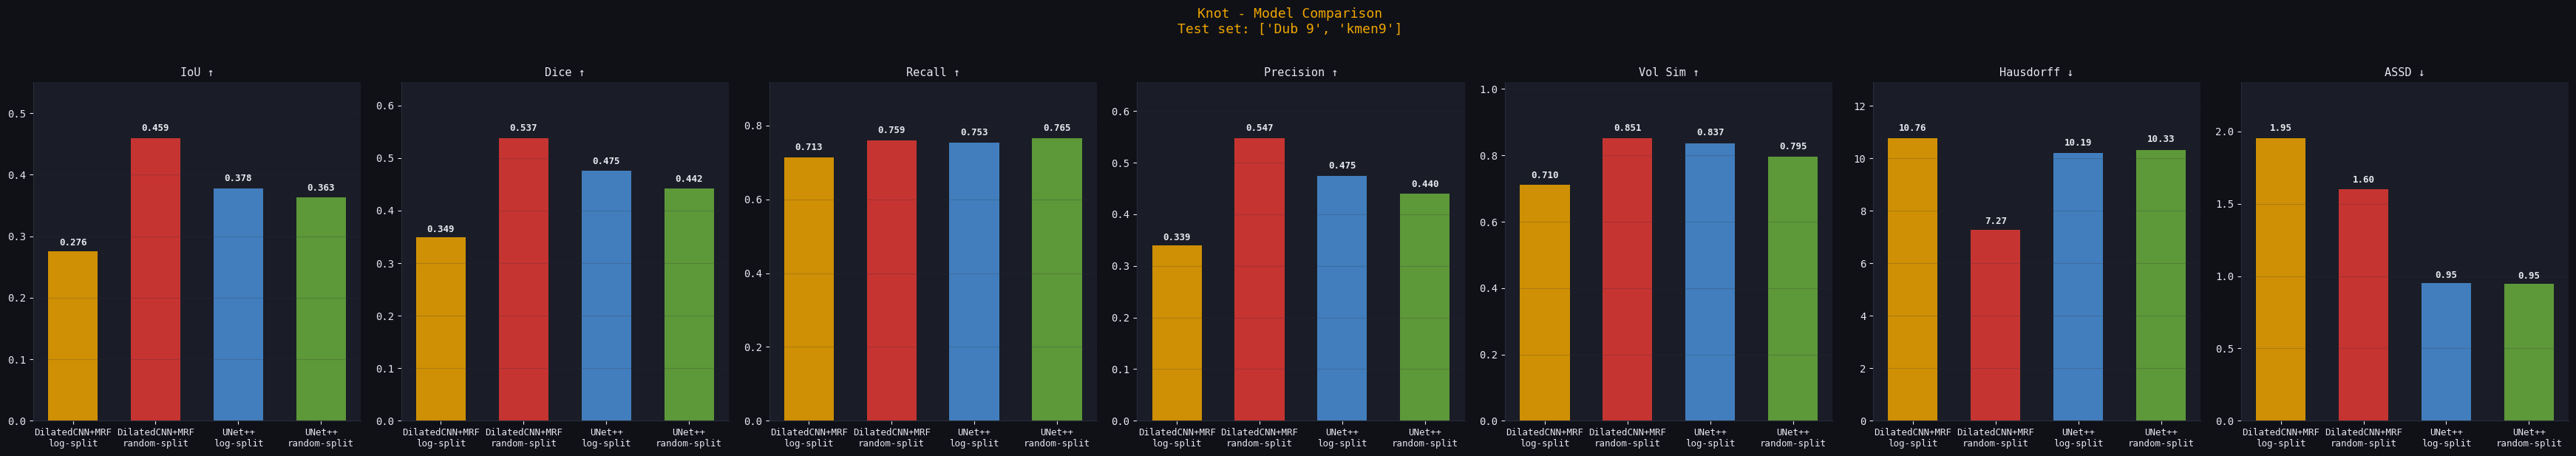

Saved → ./outputs/evaluation\comparison_crack.png


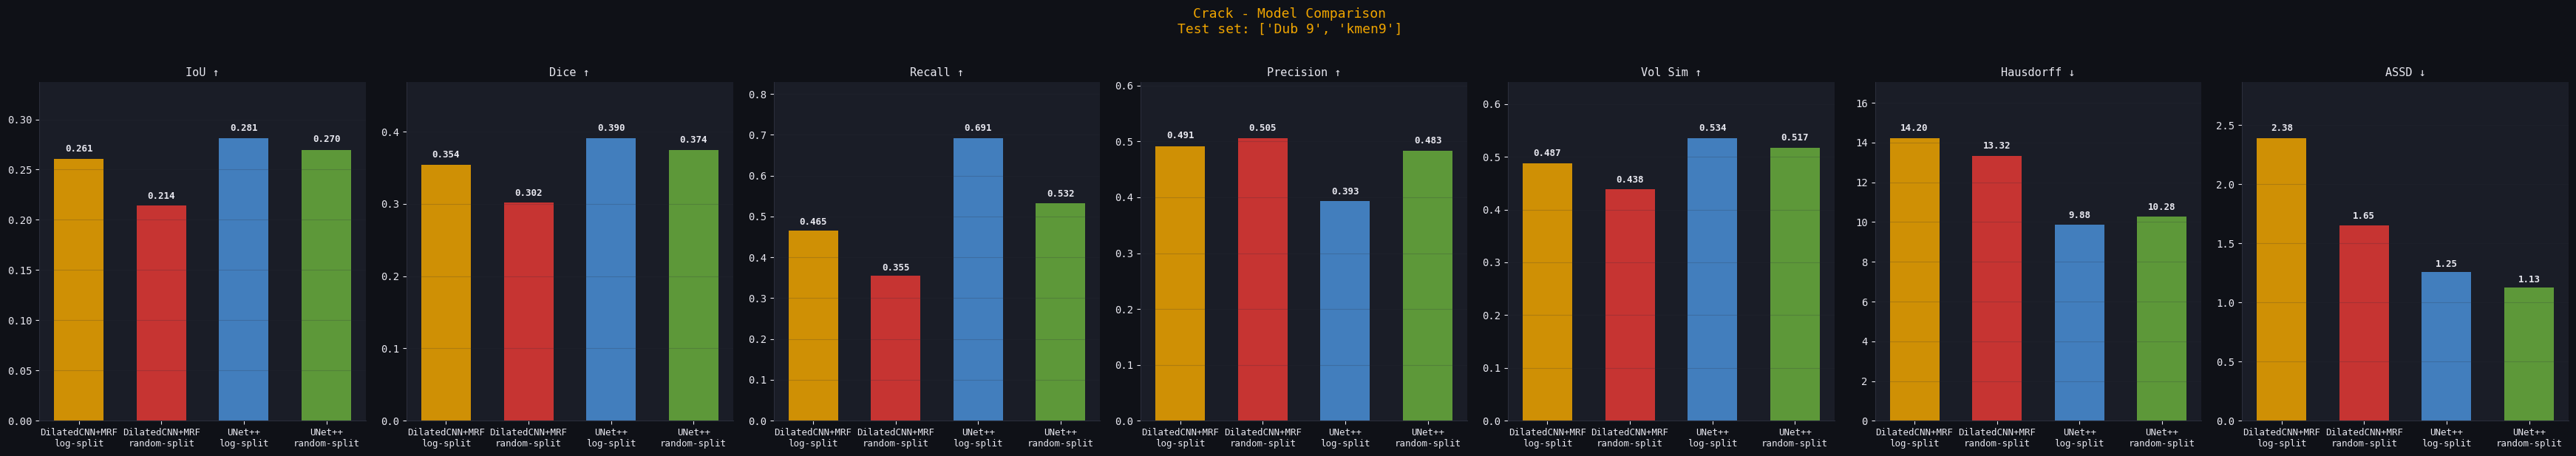

Saved → ./outputs/evaluation\comparison_defect.png


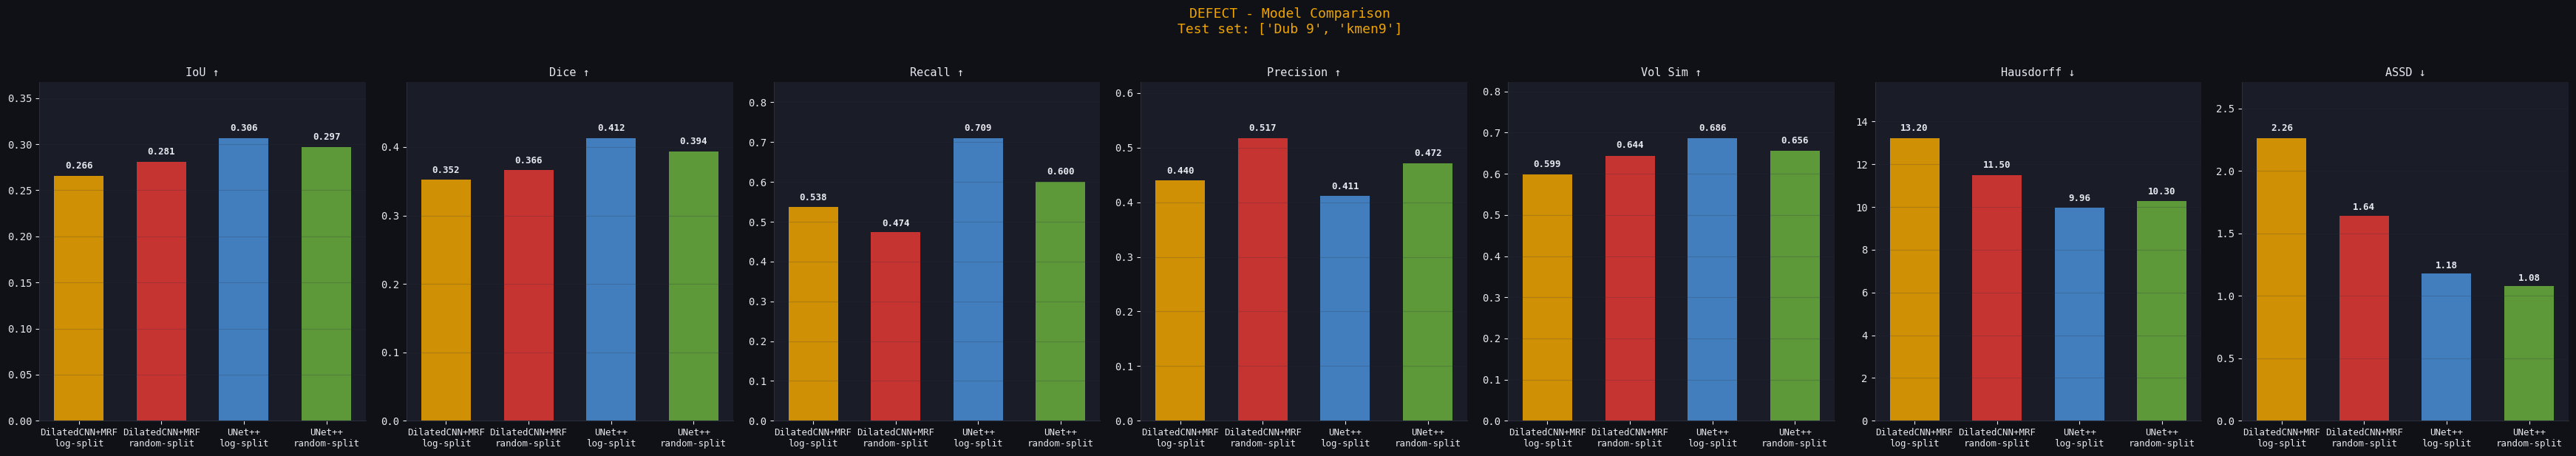

In [17]:
from IPython.display import display
 
PLOT_CLASSES  = ["Knot", "Crack", "DEFECT"]
METRIC_LABELS = {
    "iou": "IoU ↑", "dice": "Dice ↑", "recall": "Recall ↑",
    "precision": "Precision ↑", "vs": "Vol Sim ↑",
    "hd": "Hausdorff ↓", "assd": "ASSD ↓",
}
COLORS = ["#F0A500", "#E53935", "#4A90D9", "#6AAF3D",
          "#9B59B6", "#1ABC9C", "#E67E22"]
 
model_names = list(all_dfs.keys())
n_models    = len(model_names)
 
for cls in PLOT_CLASSES:
    fig, axes = plt.subplots(
        1, len(METRICS),
        figsize=(5 * len(METRICS), 6),
        facecolor=DARK_BG
    )
    sub = summary_df[summary_df["class"] == cls]
 
    for col, metric in enumerate(METRICS):
        ax   = axes[col]
        vals = [
            float(sub[sub["model"] == m][metric].values[0])
            if len(sub[sub["model"] == m]) > 0 else float("nan")
            for m in model_names
        ]
        bars = ax.bar(range(n_models), vals,
                      color=COLORS[:n_models], alpha=0.85, width=0.6)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                label = f"{val:.2f}" if metric in ["hd", "assd"] else f"{val:.3f}"
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 1.02,
                        label, ha="center", va="bottom",
                        fontsize=9, color=TEXT_COL, fontweight="bold")
        ax.set_xticks(range(n_models))
        ax.set_xticklabels(
            [m.replace(" ", "\n") for m in model_names],
            fontsize=9
        )
        ax.set_title(METRIC_LABELS[metric], fontsize=11, pad=6)
        ax.grid(alpha=0.2, axis="y")
        ax.set_ylim(0, max(v for v in vals if not np.isnan(v)) * 1.2
                    if any(not np.isnan(v) for v in vals) else 1)
 
    fig.suptitle(
        f"{cls} - Model Comparison\nTest set: {COMMON_TEST_LOGS}",
        fontsize=13, color=ACCENT, y=1.02
    )
    plt.tight_layout()
    save_path = os.path.join(OUT_DIR, f"comparison_{cls.lower()}.png")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {save_path}")
    display(fig)
    plt.close(fig)

In [30]:
print(f"\n{'═'*100}")
print(f"  CRACK METRICS PER LOG - ALL MODELS")
print(f"{'═'*100}")
 
crack_rows = []
for model_name, df in all_dfs.items():
    cdf = df[df["class"] == "Crack"]
    for log_id, grp in cdf.groupby("log"):
        crack_rows.append({
            "model":     model_name,
            "log":       log_id,
            "n_imgs":    len(grp),
            "recall":    grp["recall"].mean(skipna=True),
            "precision": grp["precision"].mean(skipna=True),
            "vs":        grp["vs"].mean(skipna=True),
            "hd":        grp["hd"].mean(skipna=True),
            "assd":      grp["assd"].mean(skipna=True),
        })
 
crack_log_df = pd.DataFrame(crack_rows)
 
# filter to logs with meaningful crack pixel count
CRACK_LOG_METRICS = ["recall", "precision", "vs", "hd", "assd"]
 
for metric in CRACK_LOG_METRICS:
    pivot = crack_log_df.pivot_table(
        index="log", columns="model", values=metric, aggfunc="mean"
    )
    # only show logs where at least one model has a non-nan value
    pivot = pivot.dropna(how="all")
    fmt = lambda x: f"{x:.2f}" if metric in ["hd", "assd"] else f"{x:.4f}"
    arrow = "↓" if metric in ["hd", "assd"] else "↑"
    print(f"\n── Crack {metric.upper()} {arrow} {'─'*(88 - len(metric))}")
    print(pivot.to_string(float_format=fmt))


════════════════════════════════════════════════════════════════════════════════════════════════════
  CRACK METRICS PER LOG - ALL MODELS
════════════════════════════════════════════════════════════════════════════════════════════════════

── Crack RECALL ↑ ──────────────────────────────────────────────────────────────────────────────────
model  DilatedCNN+MRF log-split  DilatedCNN+MRF random-split  UNet++ log-split  UNet++ random-split
log                                                                                                
Dub 9                    0.4093                       0.2230            0.7809               0.7093
kmen9                    0.4964                       0.4303            0.6395               0.4320

── Crack PRECISION ↑ ───────────────────────────────────────────────────────────────────────────────
model  DilatedCNN+MRF log-split  DilatedCNN+MRF random-split  UNet++ log-split  UNet++ random-split
log                                                     